# 

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cosm


def calculate_fluxonium_energies(EJ, EC, EL, cutoff, flux_fraction, truncated_dim):

    phi_ext = 2 * np.pi * flux_fraction
    omega_p = np.sqrt(8*EC*EL)

    H0 = np.zeros((cutoff, cutoff), dtype=float)
    for n in range(cutoff):
        H0[n, n] = omega_p*(n+0.5)
    
    phi_zpf = (2.0*EC/EL) ** 0.25
    phi_matrix = np.zeros((cutoff, cutoff), dtype=float)
    for m in range (1, cutoff):
        phi_matrix[m-1, m] = phi_zpf*np.sqrt(m)
        phi_matrix[m, m-1] = phi_zpf*np.sqrt(m)
    phi_matrix = phi_matrix - phi_ext*np.identity(cutoff)
    
    H = H0 - EJ*cosm(phi_matrix)
    
    energies, states = np.linalg.eigh(H)
    lowest_energies = energies[:truncated_dim]

    return lowest_energies

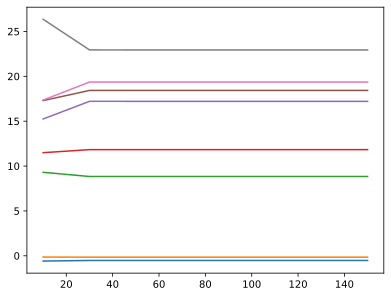

In [22]:
EJ = 8.91
EC = 2.48
EL = 0.53
cutoffs = [10, 30, 50, 70, 90, 110, 130, 150]
flux_fraction = 0.5
truncated_dim = 8

energy_results = []

for cutoff in cutoffs:
    lowest_energies = calculate_fluxonium_energies(EJ, EC, EL, cutoff, flux_fraction, truncated_dim)
    energy_results.append(lowest_energies)
    
energy_results = np.array(energy_results)
plt.plot(cutoffs, energy_results)

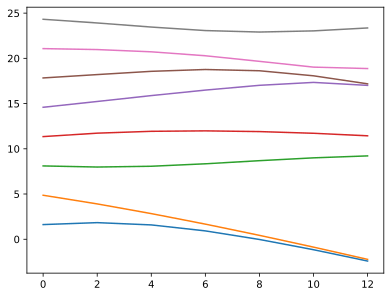

In [25]:
EJ = [0, 2, 4, 6, 8, 10, 12]
EC = 2.48
EL = 0.53
cutoff = 110
flux_fraction = 0.5
truncated_dim = 8

energy_results = []

for ej in EJ:
    lowest_energies = calculate_fluxonium_energies(ej, EC, EL, cutoff, flux_fraction, truncated_dim)
    energy_results.append(lowest_energies)
    
energy_results = np.array(energy_results)
plt.plot(EJ, energy_results)

In [15]:
import scqubits as scq

fluxonium = scq.Fluxonium(
    EJ=8.91,
    EC=2.48,
    EL=0.53,
    flux=0.0,
    cutoff=110,
    truncated_dim=6,
)

energies = fluxonium.eigenvals(evals_count=6)

print(energies)
print("Relative energies:")
print(energies - energies[0])

[-2.71645226  6.4499534   6.74739203  8.40088611 14.44870977 17.22312042]
Relative energies:
[ 0.          9.16640566  9.4638443  11.11733838 17.16516203 19.93957269]


In [2]:
import scqubits as scq

print(scq.__version__)

4.3.1


In [26]:
N = 4
A = np.zeros((N,N))
print(A)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
